
# 🧭 CareerCompass — ML-Powered Career Guidance for South African Youth

**Problem:** Millions of SA children, matric leavers and unemployed youth lack access to
qualified career counsellors, leading to mismatched career choices, high dropout rates and
wasted potential.

**Solution:** CareerCompass collects a student's **academic marks**, **RIASEC interests**,
**Big Five personality traits**, and **practical constraints** (budget, study duration) through
a short questionnaire, then returns **personalised, explainable career recommendations** with
concrete next steps — mapped to South African subjects (NSC/APS), qualification pathways, and
SETA sectors.

## How this notebook is organised
1. **Career knowledge base** — 53 SA-relevant careers curated in the spirit of O\*NET (RIASEC +
   skill/personality profiles) and SETA sector taxonomies.
2. **Synthetic training data** — since no public, individually-labelled "student → ideal career"
   dataset exists for South Africa, we generate a realistic synthetic training set anchored to
   the career knowledge base (a standard technique when bootstrapping recommender systems).
3. **Hybrid recommendation model**:
   - *Content-based layer*: cosine similarity between the student's interest/personality vectors
     and each career's ideal profile, plus rule-based subject and budget/duration matching.
   - *ML layer*: a `RandomForestClassifier` learns to predict the most suitable **career sector**
     from a student's full profile, and its probabilities are blended in to re-rank results and
     to provide global feature-importance interpretability.
4. **Explanation engine** — turns every recommendation into a plain-English reason.
5. **Evaluation** — train/test accuracy, top-3 accuracy, feature importances.
6. **Interactive demo** — fill in the questionnaire and get live recommendations.
7. **Deployment notes** — how to turn this into the web app described in the brief.

> 📌 This notebook is fully self-contained — no external downloads required — so it runs
> end-to-end on Kaggle with **Settings → Internet: off** if needed.


In [15]:

!pip install -q scikit-learn pandas numpy matplotlib seaborn ipywidgets joblib --quiet


In [16]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, top_k_accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RNG = np.random.default_rng(42)
print("Environment ready.")


Environment ready.



## 1. Career Knowledge Base

Each career record includes:
- **RIASEC profile** (Realistic, Investigative, Artistic, Social, Enterprising, Conventional) — the Holland Code interest model used throughout modern career guidance (and O\*NET).
- **Big Five personality fit** (Openness, Conscientiousness, Extraversion, Agreeableness, Neuroticism).
- **Required NSC subjects & minimum marks**, and an approximate **APS** cut-off.
- **Study duration, budget tier, entry salary estimate, growth outlook**.
- **SETA sector** alignment and **actionable next steps** (bursaries, programme names, registration bodies) specific to South Africa.


In [17]:
"""
CareerCompass - Curated Career Knowledge Base
================================================
Structured in the spirit of O*NET (RIASEC interest model, work-context/skill
profiles) and aligned to South African NSC subjects, APS admission scoring,
and SETA sector categories, since no single public dataset combines all of
these for the SA youth-guidance context. Each career record is hand-curated
from O*NET occupational summaries, CareerHelp/CareerJunction SA salary
benchmarks, and DHET/SETA sector lists.

RIASEC = Holland Code interest dimensions:
  R = Realistic, I = Investigative, A = Artistic,
  S = Social, E = Enterprising, C = Conventional
Personality dimensions use the Big Five (OCEAN), scored 0-1 as the IDEAL
profile for someone thriving in that career.
"""

CAREERS = [
    # ---------------- HEALTH ----------------
    dict(name="Medical Doctor", sector="Health", seta="HWSETA",
         riasec=dict(R=0.3, I=0.9, A=0.1, S=0.8, E=0.3, C=0.4),
         personality=dict(openness=0.6, conscientiousness=0.9, extraversion=0.5, agreeableness=0.7, neuroticism=0.2),
         subjects={"Mathematics": 70, "Physical Sciences": 70, "Life Sciences": 70, "English": 60},
         min_aps=38, duration_years=6, budget_level=3, salary_entry=420000, growth_outlook="High",
         description="Diagnose and treat illness; requires an MBChB degree and community service year.",
         next_steps=["Achieve 70%+ in Maths, Physical Sciences and Life Sciences",
                      "Apply to MBChB programmes (Wits, UCT, UP, UKZN, Stellenbosch, SMU)",
                      "Look into HPCSA and NSFAS/HWSETA bursaries for medicine"]),
    dict(name="Professional Nurse", sector="Health", seta="HWSETA",
         riasec=dict(R=0.3, I=0.5, A=0.1, S=0.9, E=0.2, C=0.4),
         personality=dict(openness=0.4, conscientiousness=0.8, extraversion=0.6, agreeableness=0.9, neuroticism=0.2),
         subjects={"Mathematics": 50, "Life Sciences": 60, "English": 55},
         min_aps=26, duration_years=4, budget_level=2, salary_entry=250000, growth_outlook="High",
         description="Provide patient care in hospitals, clinics and communities.",
         next_steps=["Aim for 60%+ Life Sciences", "Apply to nursing colleges or university B.Cur programmes",
                      "Check SANC registration requirements and NSFAS funding"]),
    dict(name="Pharmacist", sector="Health", seta="HWSETA",
         riasec=dict(R=0.2, I=0.85, A=0.1, S=0.5, E=0.3, C=0.6),
         personality=dict(openness=0.5, conscientiousness=0.9, extraversion=0.4, agreeableness=0.6, neuroticism=0.2),
         subjects={"Mathematics": 65, "Physical Sciences": 65, "Life Sciences": 60},
         min_aps=32, duration_years=4, budget_level=3, salary_entry=350000, growth_outlook="Medium",
         description="Dispense medication and advise on drug therapy.",
         next_steps=["Target 65%+ in Maths and Physical Sciences", "Apply for B.Pharm at Rhodes, Wits, UWC, TUT",
                      "Register as an intern with SAPC after graduating"]),
    dict(name="Physiotherapist", sector="Health", seta="HWSETA",
         riasec=dict(R=0.6, I=0.6, A=0.2, S=0.8, E=0.2, C=0.3),
         personality=dict(openness=0.5, conscientiousness=0.8, extraversion=0.6, agreeableness=0.8, neuroticism=0.2),
         subjects={"Mathematics": 60, "Physical Sciences": 55, "Life Sciences": 60},
         min_aps=30, duration_years=4, budget_level=3, salary_entry=280000, growth_outlook="Medium",
         description="Help patients recover movement and manage pain through physical therapy.",
         next_steps=["Keep Life Sciences and Physical Sciences above 55%",
                      "Apply to Wits, UCT, UP, UWC physiotherapy programmes"]),
    dict(name="Emergency Medical Technician (Paramedic)", sector="Health", seta="HWSETA",
         riasec=dict(R=0.7, I=0.5, A=0.1, S=0.7, E=0.3, C=0.3),
         personality=dict(openness=0.4, conscientiousness=0.8, extraversion=0.6, agreeableness=0.7, neuroticism=0.2),
         subjects={"Mathematics": 45, "Life Sciences": 50, "English": 50},
         min_aps=20, duration_years=2, budget_level=1, salary_entry=180000, growth_outlook="Medium",
         description="Provide emergency medical care and transport for patients.",
         next_steps=["Complete a Higher Certificate/Diploma in Emergency Medical Care",
                      "Register with the HPCSA", "Look at TVET college EMS programmes"]),

    # ---------------- ENGINEERING & TECH ----------------
    dict(name="Civil Engineer", sector="Engineering", seta="CETA",
         riasec=dict(R=0.8, I=0.8, A=0.2, S=0.2, E=0.4, C=0.5),
         personality=dict(openness=0.5, conscientiousness=0.8, extraversion=0.3, agreeableness=0.4, neuroticism=0.2),
         subjects={"Mathematics": 70, "Physical Sciences": 65},
         min_aps=34, duration_years=4, budget_level=3, salary_entry=340000, growth_outlook="High",
         description="Design and oversee construction of infrastructure like roads, bridges and buildings.",
         next_steps=["Push Maths and Physical Sciences above 65%",
                      "Apply to BEng/BSc Civil Engineering programmes",
                      "Explore CETA/ECSA-linked bursaries"]),
    dict(name="Electrical Engineer", sector="Engineering", seta="merSETA",
         riasec=dict(R=0.8, I=0.85, A=0.15, S=0.2, E=0.35, C=0.5),
         personality=dict(openness=0.55, conscientiousness=0.8, extraversion=0.3, agreeableness=0.4, neuroticism=0.2),
         subjects={"Mathematics": 75, "Physical Sciences": 70},
         min_aps=36, duration_years=4, budget_level=3, salary_entry=360000, growth_outlook="High",
         description="Design electrical systems, power grids and electronics.",
         next_steps=["Target 70%+ Maths and Physical Sciences", "Apply to BEng Electrical Engineering",
                      "Look at Eskom, Transnet and merSETA bursaries"]),
    dict(name="Mechanical Engineer", sector="Engineering", seta="merSETA",
         riasec=dict(R=0.85, I=0.8, A=0.15, S=0.15, E=0.3, C=0.45),
         personality=dict(openness=0.5, conscientiousness=0.8, extraversion=0.3, agreeableness=0.4, neuroticism=0.2),
         subjects={"Mathematics": 75, "Physical Sciences": 70},
         min_aps=36, duration_years=4, budget_level=3, salary_entry=360000, growth_outlook="Medium",
         description="Design and build machinery, engines and mechanical systems.",
         next_steps=["Maintain 70%+ Maths/Physical Sciences", "Apply to BEng Mechanical Engineering programmes"]),
    dict(name="Software Developer", sector="ICT", seta="MICT SETA",
         riasec=dict(R=0.4, I=0.85, A=0.4, S=0.2, E=0.3, C=0.55),
         personality=dict(openness=0.6, conscientiousness=0.7, extraversion=0.3, agreeableness=0.4, neuroticism=0.25),
         subjects={"Mathematics": 60, "English": 55},
         min_aps=26, duration_years=3, budget_level=2, salary_entry=300000, growth_outlook="High",
         description="Build software applications, websites and systems.",
         next_steps=["Build Maths to 60%+; start free coding courses (HarvardX CS50, freeCodeCamp)",
                      "Apply to BSc Computer Science / IT diplomas, or bootcamps like WeThinkCode_ / CodeSpace",
                      "Build a portfolio on GitHub"]),
    dict(name="Data Scientist / Analyst", sector="ICT", seta="MICT SETA",
         riasec=dict(R=0.2, I=0.9, A=0.3, S=0.2, E=0.4, C=0.65),
         personality=dict(openness=0.65, conscientiousness=0.75, extraversion=0.3, agreeableness=0.4, neuroticism=0.25),
         subjects={"Mathematics": 70, "English": 55},
         min_aps=30, duration_years=3, budget_level=2, salary_entry=320000, growth_outlook="High",
         description="Extract insights from data to guide business decisions using statistics and ML.",
         next_steps=["Push Maths above 70%", "Study BSc Data Science / Statistics / Computer Science",
                      "Practise with free courses (Kaggle Learn, Coursera)"]),
    dict(name="Network / IT Support Technician", sector="ICT", seta="MICT SETA",
         riasec=dict(R=0.6, I=0.6, A=0.1, S=0.3, E=0.3, C=0.6),
         personality=dict(openness=0.4, conscientiousness=0.7, extraversion=0.4, agreeableness=0.5, neuroticism=0.25),
         subjects={"Mathematics": 45, "English": 50},
         min_aps=18, duration_years=1, budget_level=1, salary_entry=160000, growth_outlook="Medium",
         description="Install, maintain and troubleshoot computer networks and hardware.",
         next_steps=["Complete A+/N+ certifications or a TVET IT diploma",
                      "Look at MICT SETA learnerships"]),
    dict(name="Cybersecurity Analyst", sector="ICT", seta="MICT SETA",
         riasec=dict(R=0.4, I=0.85, A=0.2, S=0.2, E=0.3, C=0.65),
         personality=dict(openness=0.55, conscientiousness=0.8, extraversion=0.25, agreeableness=0.4, neuroticism=0.25),
         subjects={"Mathematics": 60, "English": 55},
         min_aps=26, duration_years=3, budget_level=2, salary_entry=310000, growth_outlook="High",
         description="Protect organisations from cyberattacks and data breaches.",
         next_steps=["Study BSc IT/Computer Science with a security focus",
                      "Pursue CompTIA Security+ certification"]),
    dict(name="Artisan Electrician", sector="Trades", seta="merSETA",
         riasec=dict(R=0.9, I=0.4, A=0.1, S=0.2, E=0.2, C=0.4),
         personality=dict(openness=0.35, conscientiousness=0.75, extraversion=0.35, agreeableness=0.5, neuroticism=0.2),
         subjects={"Mathematics": 45, "Physical Sciences": 40},
         min_aps=15, duration_years=3, budget_level=1, salary_entry=170000, growth_outlook="High",
         description="Install and maintain electrical wiring and systems as a qualified trade.",
         next_steps=["Enrol in a TVET N-course or apprenticeship in electrical trade",
                      "Complete a trade test to become a qualified artisan (merSETA)"]),
    dict(name="Artisan - Plumber", sector="Trades", seta="CETA",
         riasec=dict(R=0.9, I=0.3, A=0.1, S=0.2, E=0.25, C=0.35),
         personality=dict(openness=0.3, conscientiousness=0.7, extraversion=0.35, agreeableness=0.5, neuroticism=0.2),
         subjects={"Mathematics": 40},
         min_aps=14, duration_years=3, budget_level=1, salary_entry=150000, growth_outlook="Medium",
         description="Install and repair piping and water systems as a qualified trade.",
         next_steps=["Enrol at a TVET college for plumbing", "Complete an apprenticeship and trade test"]),
    dict(name="Motor Mechanic / Auto Technician", sector="Trades", seta="merSETA",
         riasec=dict(R=0.9, I=0.45, A=0.1, S=0.15, E=0.2, C=0.35),
         personality=dict(openness=0.3, conscientiousness=0.7, extraversion=0.35, agreeableness=0.45, neuroticism=0.2),
         subjects={"Mathematics": 40, "Physical Sciences": 40},
         min_aps=14, duration_years=3, budget_level=1, salary_entry=150000, growth_outlook="Medium",
         description="Diagnose and repair vehicles as a qualified automotive trade.",
         next_steps=["Enrol in a TVET automotive repair programme or dealership apprenticeship"]),

    # ---------------- BUSINESS & FINANCE ----------------
    dict(name="Chartered Accountant (CA)", sector="Finance", seta="FASSET",
         riasec=dict(R=0.1, I=0.6, A=0.1, S=0.2, E=0.5, C=0.9),
         personality=dict(openness=0.4, conscientiousness=0.9, extraversion=0.35, agreeableness=0.4, neuroticism=0.2),
         subjects={"Mathematics": 70, "Accounting": 70, "English": 55},
         min_aps=32, duration_years=4, budget_level=2, salary_entry=330000, growth_outlook="High",
         description="Audit, tax and financial management professional (SAICA-registered).",
         next_steps=["Keep Maths and Accounting above 70%", "Study a SAICA-accredited BCom Accounting degree",
                      "Explore FASSET/Big-4 bursary programmes"]),
    dict(name="Financial Advisor / Planner", sector="Finance", seta="INSETA",
         riasec=dict(R=0.1, I=0.5, A=0.1, S=0.55, E=0.7, C=0.65),
         personality=dict(openness=0.4, conscientiousness=0.75, extraversion=0.65, agreeableness=0.55, neuroticism=0.25),
         subjects={"Mathematics": 55, "English": 55},
         min_aps=24, duration_years=3, budget_level=2, salary_entry=220000, growth_outlook="Medium",
         description="Advise clients on investments, insurance and retirement planning.",
         next_steps=["Study BCom Finance/Investment Management", "Pursue CFP certification via FPI"]),
    dict(name="Actuary", sector="Finance", seta="INSETA",
         riasec=dict(R=0.1, I=0.9, A=0.1, S=0.15, E=0.3, C=0.85),
         personality=dict(openness=0.5, conscientiousness=0.9, extraversion=0.25, agreeableness=0.35, neuroticism=0.2),
         subjects={"Mathematics": 85, "English": 55},
         min_aps=40, duration_years=4, budget_level=3, salary_entry=380000, growth_outlook="High",
         description="Use maths and statistics to assess financial risk for insurers/pension funds.",
         next_steps=["Push Maths above 85%", "Study BSc/BCom Actuarial Science (UCT, Wits, UP, UFS)",
                      "Begin ASSA actuarial exams while studying"]),
    dict(name="Marketing Manager", sector="Business", seta="FASSET",
         riasec=dict(R=0.1, I=0.4, A=0.6, S=0.5, E=0.85, C=0.4),
         personality=dict(openness=0.7, conscientiousness=0.6, extraversion=0.75, agreeableness=0.55, neuroticism=0.3),
         subjects={"Mathematics": 50, "English": 60},
         min_aps=24, duration_years=3, budget_level=2, salary_entry=260000, growth_outlook="Medium",
         description="Plan and execute campaigns to promote products/brands.",
         next_steps=["Study BCom Marketing or Communications", "Build a portfolio with social-media/campaign projects"]),
    dict(name="Human Resources Manager", sector="Business", seta="Services SETA",
         riasec=dict(R=0.1, I=0.35, A=0.2, S=0.8, E=0.6, C=0.55),
         personality=dict(openness=0.5, conscientiousness=0.75, extraversion=0.6, agreeableness=0.75, neuroticism=0.25),
         subjects={"Mathematics": 45, "English": 60},
         min_aps=22, duration_years=3, budget_level=2, salary_entry=250000, growth_outlook="Medium",
         description="Manage recruitment, employee relations and workplace policy.",
         next_steps=["Study BCom/BA Human Resource Management", "Join SABPP for professional registration"]),
    dict(name="Entrepreneur / Small Business Owner", sector="Business", seta="Services SETA",
         riasec=dict(R=0.4, I=0.5, A=0.4, S=0.4, E=0.9, C=0.4),
         personality=dict(openness=0.75, conscientiousness=0.65, extraversion=0.75, agreeableness=0.45, neuroticism=0.3),
         subjects={"Mathematics": 45, "English": 50},
         min_aps=16, duration_years=1, budget_level=1, salary_entry=0, growth_outlook="Variable",
         description="Start and run your own business or venture.",
         next_steps=["Take a short course in small-business management (SEDA, SAB Foundation)",
                      "Explore NYDA youth business grants and mentorship programmes"]),
    dict(name="Logistics / Supply Chain Manager", sector="Business", seta="TETA",
         riasec=dict(R=0.4, I=0.55, A=0.1, S=0.3, E=0.65, C=0.65),
         personality=dict(openness=0.45, conscientiousness=0.8, extraversion=0.5, agreeableness=0.45, neuroticism=0.25),
         subjects={"Mathematics": 55, "English": 50},
         min_aps=22, duration_years=3, budget_level=2, salary_entry=240000, growth_outlook="High",
         description="Coordinate the movement of goods from suppliers to customers.",
         next_steps=["Study BCom/Diploma in Logistics or Supply Chain Management",
                      "Look at TETA learnerships"]),
    dict(name="Retail / Sales Manager", sector="Business", seta="W&RSETA",
         riasec=dict(R=0.2, I=0.3, A=0.2, S=0.5, E=0.8, C=0.45),
         personality=dict(openness=0.5, conscientiousness=0.65, extraversion=0.8, agreeableness=0.55, neuroticism=0.3),
         subjects={"Mathematics": 45, "English": 50},
         min_aps=18, duration_years=2, budget_level=1, salary_entry=180000, growth_outlook="Medium",
         description="Manage retail store operations, staff and sales targets.",
         next_steps=["Consider W&RSETA learnerships", "Study a Diploma in Retail Business Management"]),

    # ---------------- EDUCATION & SOCIAL SERVICES ----------------
    dict(name="Foundation Phase Teacher", sector="Education", seta="ETDP SETA",
         riasec=dict(R=0.2, I=0.3, A=0.4, S=0.9, E=0.3, C=0.4),
         personality=dict(openness=0.5, conscientiousness=0.8, extraversion=0.65, agreeableness=0.85, neuroticism=0.2),
         subjects={"Mathematics": 45, "English": 55},
         min_aps=22, duration_years=4, budget_level=1, salary_entry=220000, growth_outlook="High",
         description="Teach young learners (Grade R-3) foundational literacy and numeracy.",
         next_steps=["Study a B.Ed Foundation Phase degree",
                      "Apply for the Funza Lushaka teaching bursary"]),
    dict(name="High School Subject Teacher", sector="Education", seta="ETDP SETA",
         riasec=dict(R=0.2, I=0.5, A=0.35, S=0.85, E=0.3, C=0.4),
         personality=dict(openness=0.55, conscientiousness=0.75, extraversion=0.6, agreeableness=0.75, neuroticism=0.25),
         subjects={"Mathematics": 55, "English": 55},
         min_aps=24, duration_years=4, budget_level=1, salary_entry=230000, growth_outlook="High",
         description="Teach a specialised subject (e.g. Maths, Science) at high-school level.",
         next_steps=["Study a B.Ed with your subject specialisation",
                      "Apply for the Funza Lushaka bursary, especially for Maths/Science"]),
    dict(name="Social Worker", sector="Social Services", seta="HWSETA",
         riasec=dict(R=0.15, I=0.4, A=0.2, S=0.95, E=0.3, C=0.4),
         personality=dict(openness=0.5, conscientiousness=0.7, extraversion=0.55, agreeableness=0.9, neuroticism=0.25),
         subjects={"English": 55},
         min_aps=22, duration_years=4, budget_level=1, salary_entry=210000, growth_outlook="High",
         description="Support vulnerable individuals and families through counselling and case work.",
         next_steps=["Study a BSW (Bachelor of Social Work)",
                      "Register with the SACSSP after graduating"]),
    dict(name="Psychologist (Counselling)", sector="Social Services", seta="HWSETA",
         riasec=dict(R=0.1, I=0.7, A=0.3, S=0.9, E=0.3, C=0.35),
         personality=dict(openness=0.6, conscientiousness=0.75, extraversion=0.5, agreeableness=0.85, neuroticism=0.2),
         subjects={"Mathematics": 50, "English": 60, "Life Sciences": 50},
         min_aps=30, duration_years=6, budget_level=3, salary_entry=260000, growth_outlook="Medium",
         description="Assess and support mental health and wellbeing (requires honours + masters).",
         next_steps=["Study BA/BSocSci Psychology, then honours and masters",
                      "Register with the HPCSA as an intern psychologist"]),
    dict(name="Community Development Worker", sector="Social Services", seta="LGSETA",
         riasec=dict(R=0.3, I=0.35, A=0.2, S=0.9, E=0.4, C=0.35),
         personality=dict(openness=0.5, conscientiousness=0.65, extraversion=0.6, agreeableness=0.85, neuroticism=0.25),
         subjects={"English": 50},
         min_aps=16, duration_years=2, budget_level=1, salary_entry=160000, growth_outlook="Medium",
         description="Coordinate community upliftment programmes in health, education or welfare.",
         next_steps=["Study a Diploma/Certificate in Community Development",
                      "Volunteer with local NGOs to build experience"]),
    dict(name="Paralegal / Legal Assistant", sector="Legal", seta="Services SETA",
         riasec=dict(R=0.15, I=0.6, A=0.2, S=0.4, E=0.4, C=0.75),
         personality=dict(openness=0.45, conscientiousness=0.85, extraversion=0.4, agreeableness=0.5, neuroticism=0.25),
         subjects={"English": 60},
         min_aps=20, duration_years=2, budget_level=1, salary_entry=180000, growth_outlook="Medium",
         description="Support attorneys with research, documentation and case preparation.",
         next_steps=["Study a Paralegal Diploma or LLB (for attorney route)"]),
    dict(name="Attorney / Lawyer", sector="Legal", seta="Services SETA",
         riasec=dict(R=0.1, I=0.65, A=0.2, S=0.5, E=0.6, C=0.6),
         personality=dict(openness=0.5, conscientiousness=0.85, extraversion=0.55, agreeableness=0.5, neuroticism=0.25),
         subjects={"English": 65},
         min_aps=32, duration_years=4, budget_level=2, salary_entry=280000, growth_outlook="Medium",
         description="Advise and represent clients on legal matters.",
         next_steps=["Study an LLB degree", "Complete articles of clerkship and board exams to become an attorney"]),
    dict(name="Police Officer", sector="Public Safety", seta="Services SETA",
         riasec=dict(R=0.7, I=0.35, A=0.1, S=0.6, E=0.4, C=0.4),
         personality=dict(openness=0.35, conscientiousness=0.75, extraversion=0.55, agreeableness=0.55, neuroticism=0.2),
         subjects={"English": 45},
         min_aps=16, duration_years=1, budget_level=1, salary_entry=190000, growth_outlook="Medium",
         description="Enforce the law and protect communities.",
         next_steps=["Apply directly to SAPS recruitment", "Pass fitness, psychometric and background checks"]),

    # ---------------- CREATIVE & MEDIA ----------------
    dict(name="Graphic Designer", sector="Creative", seta="MICT SETA",
         riasec=dict(R=0.2, I=0.3, A=0.9, S=0.2, E=0.4, C=0.35),
         personality=dict(openness=0.85, conscientiousness=0.55, extraversion=0.4, agreeableness=0.45, neuroticism=0.3),
         subjects={"English": 50},
         min_aps=18, duration_years=3, budget_level=2, salary_entry=180000, growth_outlook="Medium",
         description="Create visual concepts for branding, media and digital products.",
         next_steps=["Study a Diploma/Degree in Graphic Design",
                      "Build a portfolio on Behance and freelance early"]),
    dict(name="Film & TV Production", sector="Creative", seta="MICT SETA",
         riasec=dict(R=0.4, I=0.3, A=0.9, S=0.4, E=0.5, C=0.25),
         personality=dict(openness=0.85, conscientiousness=0.55, extraversion=0.55, agreeableness=0.45, neuroticism=0.3),
         subjects={"English": 50},
         min_aps=18, duration_years=3, budget_level=2, salary_entry=170000, growth_outlook="Medium",
         description="Plan and produce film, television or digital video content.",
         next_steps=["Study Film & Media Production", "Gain experience on student/community productions"]),
    dict(name="Journalist / Media Writer", sector="Creative", seta="MICT SETA",
         riasec=dict(R=0.15, I=0.55, A=0.7, S=0.5, E=0.45, C=0.35),
         personality=dict(openness=0.75, conscientiousness=0.6, extraversion=0.55, agreeableness=0.45, neuroticism=0.3),
         subjects={"English": 65},
         min_aps=22, duration_years=3, budget_level=2, salary_entry=190000, growth_outlook="Low",
         description="Research and write news or feature content across media platforms.",
         next_steps=["Study Journalism/Media Studies", "Start a blog or student publication to build a portfolio"]),
    dict(name="Musician / Sound Engineer", sector="Creative", seta="MICT SETA",
         riasec=dict(R=0.3, I=0.3, A=0.9, S=0.3, E=0.4, C=0.2),
         personality=dict(openness=0.85, conscientiousness=0.5, extraversion=0.55, agreeableness=0.45, neuroticism=0.3),
         subjects={"English": 45},
         min_aps=16, duration_years=2, budget_level=1, salary_entry=140000, growth_outlook="Low",
         description="Compose, perform or engineer music and audio.",
         next_steps=["Study a Diploma in Music Technology/Performance", "Build an online portfolio/demo reel"]),
    dict(name="Fashion Designer", sector="Creative", seta="CTFL SETA",
         riasec=dict(R=0.4, I=0.25, A=0.9, S=0.3, E=0.5, C=0.3),
         personality=dict(openness=0.85, conscientiousness=0.6, extraversion=0.45, agreeableness=0.45, neuroticism=0.3),
         subjects={"English": 45},
         min_aps=16, duration_years=3, budget_level=2, salary_entry=150000, growth_outlook="Low",
         description="Design clothing and accessories for retail or bespoke markets.",
         next_steps=["Study Fashion Design at a university of technology",
                      "Enter local design competitions to build a name"]),
    dict(name="Architect", sector="Creative/Engineering", seta="CETA",
         riasec=dict(R=0.5, I=0.6, A=0.85, S=0.2, E=0.4, C=0.4),
         personality=dict(openness=0.8, conscientiousness=0.75, extraversion=0.35, agreeableness=0.4, neuroticism=0.25),
         subjects={"Mathematics": 60, "Physical Sciences": 50, "English": 55},
         min_aps=32, duration_years=6, budget_level=3, salary_entry=250000, growth_outlook="Medium",
         description="Design buildings and spaces balancing form, function and safety.",
         next_steps=["Push Maths above 60% and build a design portfolio",
                      "Study BAS/BArch and register with SACAP"]),

    # ---------------- AGRICULTURE, ENVIRONMENT & SCIENCE ----------------
    dict(name="Agricultural Scientist / Agronomist", sector="Agriculture", seta="AgriSETA",
         riasec=dict(R=0.6, I=0.85, A=0.15, S=0.3, E=0.3, C=0.4),
         personality=dict(openness=0.6, conscientiousness=0.75, extraversion=0.35, agreeableness=0.5, neuroticism=0.25),
         subjects={"Mathematics": 55, "Physical Sciences": 55, "Life Sciences": 65},
         min_aps=26, duration_years=4, budget_level=2, salary_entry=230000, growth_outlook="Medium",
         description="Research and improve crop/livestock production and sustainability.",
         next_steps=["Keep Life Sciences above 60%", "Study BSc Agriculture at UP, UFS, Stellenbosch"]),
    dict(name="Farm Manager", sector="Agriculture", seta="AgriSETA",
         riasec=dict(R=0.8, I=0.5, A=0.1, S=0.3, E=0.5, C=0.4),
         personality=dict(openness=0.45, conscientiousness=0.75, extraversion=0.45, agreeableness=0.5, neuroticism=0.25),
         subjects={"Mathematics": 45, "Life Sciences": 50},
         min_aps=18, duration_years=2, budget_level=1, salary_entry=180000, growth_outlook="Medium",
         description="Manage day-to-day farm operations, staff and production.",
         next_steps=["Study a Diploma in Agricultural Management",
                      "Look at AgriSETA learnerships and Land Bank youth programmes"]),
    dict(name="Environmental Scientist", sector="Environment", seta="EWSETA",
         riasec=dict(R=0.5, I=0.9, A=0.2, S=0.4, E=0.25, C=0.4),
         personality=dict(openness=0.65, conscientiousness=0.75, extraversion=0.35, agreeableness=0.55, neuroticism=0.25),
         subjects={"Mathematics": 55, "Physical Sciences": 60, "Life Sciences": 60},
         min_aps=28, duration_years=4, budget_level=2, salary_entry=230000, growth_outlook="High",
         description="Study and help protect ecosystems, water and air quality.",
         next_steps=["Study BSc Environmental Science", "Volunteer with conservation NGOs for experience"]),
    dict(name="Geologist / Mining Engineer", sector="Mining", seta="MQA",
         riasec=dict(R=0.75, I=0.85, A=0.1, S=0.2, E=0.35, C=0.4),
         personality=dict(openness=0.55, conscientiousness=0.75, extraversion=0.3, agreeableness=0.4, neuroticism=0.25),
         subjects={"Mathematics": 65, "Physical Sciences": 65},
         min_aps=30, duration_years=4, budget_level=3, salary_entry=350000, growth_outlook="Medium",
         description="Locate and extract mineral resources safely and sustainably.",
         next_steps=["Push Maths and Physical Sciences above 65%",
                      "Study BSc Geology or BEng Mining Engineering; look at MQA bursaries"]),
    dict(name="Veterinarian", sector="Health/Agriculture", seta="AgriSETA",
         riasec=dict(R=0.5, I=0.9, A=0.15, S=0.6, E=0.25, C=0.4),
         personality=dict(openness=0.55, conscientiousness=0.85, extraversion=0.4, agreeableness=0.7, neuroticism=0.2),
         subjects={"Mathematics": 65, "Physical Sciences": 65, "Life Sciences": 70},
         min_aps=36, duration_years=6, budget_level=3, salary_entry=280000, growth_outlook="Medium",
         description="Diagnose and treat animal health conditions.",
         next_steps=["Target 65-70% in the sciences", "Apply to the BVSc at the University of Pretoria (only SA option)"]),

    # ---------------- HOSPITALITY & TOURISM ----------------
    dict(name="Chef / Culinary Professional", sector="Hospitality", seta="CATHSSETA",
         riasec=dict(R=0.6, I=0.3, A=0.6, S=0.4, E=0.4, C=0.35),
         personality=dict(openness=0.6, conscientiousness=0.7, extraversion=0.5, agreeableness=0.5, neuroticism=0.3),
         subjects={"English": 45},
         min_aps=16, duration_years=2, budget_level=1, salary_entry=150000, growth_outlook="Medium",
         description="Prepare and manage food production in restaurants or hotels.",
         next_steps=["Study a Diploma in Culinary Arts (or via chef schools like Capsicum)",
                      "Look at CATHSSETA learnerships and hotel apprenticeships"]),
    dict(name="Tourism / Hospitality Manager", sector="Hospitality", seta="CATHSSETA",
         riasec=dict(R=0.3, I=0.3, A=0.35, S=0.7, E=0.65, C=0.4),
         personality=dict(openness=0.6, conscientiousness=0.7, extraversion=0.75, agreeableness=0.65, neuroticism=0.25),
         subjects={"English": 55, "Geography": 45},
         min_aps=20, duration_years=3, budget_level=2, salary_entry=170000, growth_outlook="Medium",
         description="Manage hotels, lodges or tourism operations and guest experience.",
         next_steps=["Study a Diploma in Hospitality/Tourism Management",
                      "Gain experience through internships at hotels/lodges"]),
    dict(name="Pilot (Commercial Aviation)", sector="Aviation", seta="TETA",
         riasec=dict(R=0.75, I=0.7, A=0.1, S=0.2, E=0.4, C=0.55),
         personality=dict(openness=0.5, conscientiousness=0.9, extraversion=0.4, agreeableness=0.4, neuroticism=0.15),
         subjects={"Mathematics": 60, "Physical Sciences": 60, "English": 55},
         min_aps=28, duration_years=2, budget_level=3, salary_entry=300000, growth_outlook="Medium",
         description="Fly commercial aircraft; requires a pilot's licence and hours-building.",
         next_steps=["Keep Maths/Physical Sciences above 60%",
                      "Research SAA/CAA-approved flight schools and cadet bursary programmes"]),

    # ---------------- SPORTS & OTHER ----------------
    dict(name="Sports Coach / Biokineticist", sector="Sport & Recreation", seta="SASSETA/HWSETA",
         riasec=dict(R=0.6, I=0.5, A=0.2, S=0.75, E=0.4, C=0.3),
         personality=dict(openness=0.5, conscientiousness=0.7, extraversion=0.65, agreeableness=0.6, neuroticism=0.25),
         subjects={"Life Sciences": 55, "English": 50},
         min_aps=22, duration_years=4, budget_level=2, salary_entry=200000, growth_outlook="Medium",
         description="Train athletes or help patients recover through structured exercise.",
         next_steps=["Study Sport Science / Biokinetics",
                      "Volunteer coaching school/community sport for experience"]),
    dict(name="Artisan Welder / Boilermaker", sector="Trades", seta="merSETA",
         riasec=dict(R=0.9, I=0.35, A=0.15, S=0.15, E=0.2, C=0.35),
         personality=dict(openness=0.3, conscientiousness=0.7, extraversion=0.3, agreeableness=0.45, neuroticism=0.2),
         subjects={"Mathematics": 40},
         min_aps=14, duration_years=3, budget_level=1, salary_entry=160000, growth_outlook="Medium",
         description="Join and fabricate metal structures as a qualified trade.",
         next_steps=["Enrol in a TVET welding programme or apprenticeship", "Complete a merSETA trade test"]),
    dict(name="Quantity Surveyor", sector="Engineering", seta="CETA",
         riasec=dict(R=0.4, I=0.6, A=0.15, S=0.2, E=0.45, C=0.75),
         personality=dict(openness=0.45, conscientiousness=0.85, extraversion=0.35, agreeableness=0.4, neuroticism=0.2),
         subjects={"Mathematics": 65, "Physical Sciences": 50},
         min_aps=28, duration_years=4, budget_level=2, salary_entry=280000, growth_outlook="Medium",
         description="Manage construction costs, budgets and contracts.",
         next_steps=["Push Maths above 65%", "Study BSc Quantity Surveying and register with SACQSP"]),
    dict(name="Town/Urban Planner", sector="Public Sector", seta="LGSETA",
         riasec=dict(R=0.3, I=0.65, A=0.35, S=0.4, E=0.35, C=0.55),
         personality=dict(openness=0.6, conscientiousness=0.75, extraversion=0.4, agreeableness=0.5, neuroticism=0.25),
         subjects={"Mathematics": 55, "Geography": 55},
         min_aps=26, duration_years=4, budget_level=2, salary_entry=230000, growth_outlook="Medium",
         description="Plan land use and urban development for municipalities.",
         next_steps=["Study BSc/BA Town and Regional Planning", "Register with SACPLAN"]),
    dict(name="Occupational Therapist", sector="Health", seta="HWSETA",
         riasec=dict(R=0.4, I=0.6, A=0.35, S=0.85, E=0.2, C=0.35),
         personality=dict(openness=0.55, conscientiousness=0.8, extraversion=0.55, agreeableness=0.8, neuroticism=0.2),
         subjects={"Mathematics": 55, "Physical Sciences": 50, "Life Sciences": 60},
         min_aps=30, duration_years=4, budget_level=3, salary_entry=270000, growth_outlook="Medium",
         description="Help people regain independence in daily activities after illness/injury.",
         next_steps=["Keep Life Sciences above 55%", "Apply to Wits, UCT, UP, UWC, UFS OT programmes"]),
    dict(name="Radiographer", sector="Health", seta="HWSETA",
         riasec=dict(R=0.5, I=0.7, A=0.15, S=0.65, E=0.2, C=0.5),
         personality=dict(openness=0.45, conscientiousness=0.8, extraversion=0.45, agreeableness=0.65, neuroticism=0.2),
         subjects={"Mathematics": 55, "Physical Sciences": 60, "Life Sciences": 55},
         min_aps=28, duration_years=4, budget_level=2, salary_entry=260000, growth_outlook="Medium",
         description="Operate imaging equipment (X-ray, CT, MRI) to diagnose conditions.",
         next_steps=["Keep Physical Sciences above 55%", "Apply to Diagnostic Radiography programmes"]),
    dict(name="Biotechnologist", sector="Science", seta="AgriSETA/HWSETA",
         riasec=dict(R=0.4, I=0.9, A=0.2, S=0.3, E=0.3, C=0.5),
         personality=dict(openness=0.65, conscientiousness=0.8, extraversion=0.3, agreeableness=0.45, neuroticism=0.25),
         subjects={"Mathematics": 60, "Physical Sciences": 60, "Life Sciences": 65},
         min_aps=28, duration_years=4, budget_level=2, salary_entry=240000, growth_outlook="Medium",
         description="Apply biology and technology to develop products in medicine, agriculture and industry.",
         next_steps=["Keep Life Sciences above 60%", "Study BSc Biotechnology/Microbiology"]),
    dict(name="Bricklayer / Construction Supervisor", sector="Trades", seta="CETA",
         riasec=dict(R=0.85, I=0.3, A=0.15, S=0.25, E=0.35, C=0.35),
         personality=dict(openness=0.3, conscientiousness=0.7, extraversion=0.4, agreeableness=0.5, neuroticism=0.25),
         subjects={"Mathematics": 40},
         min_aps=14, duration_years=2, budget_level=1, salary_entry=140000, growth_outlook="Medium",
         description="Build structures and supervise construction site teams.",
         next_steps=["Enrol in a TVET construction programme or on-site apprenticeship",
                      "Complete a CETA-recognised trade qualification"]),
]

RIASEC_KEYS = ["R", "I", "A", "S", "E", "C"]
BIG5_KEYS = ["openness", "conscientiousness", "extraversion", "agreeableness", "neuroticism"]

ALL_SUBJECTS = sorted({s for c in CAREERS for s in c["subjects"].keys()} |
                       {"Mathematics", "Physical Sciences", "Life Sciences", "Accounting",
                        "Business Studies", "Economics", "English", "Geography", "History"})



In [18]:

careers_df = pd.DataFrame(CAREERS)
print(f"Loaded {len(CAREERS)} careers across {careers_df['sector'].nunique()} sectors\n")
careers_df[["name", "sector", "seta", "min_aps", "duration_years", "budget_level", "salary_entry", "growth_outlook"]].head(10)


Loaded 53 careers across 21 sectors



,name,sector,seta,min_aps,duration_years,budget_level,salary_entry,growth_outlook
0,Medical Doctor,Health,HWSETA,38,6,3,420000,High
1,Professional Nurse,Health,HWSETA,26,4,2,250000,High
2,Pharmacist,Health,HWSETA,32,4,3,350000,Medium
3,Physiotherapist,Health,HWSETA,30,4,3,280000,Medium
4,Emergency Medical Technician (Paramedic),Health,HWSETA,20,2,1,180000,Medium
5,Civil Engineer,Engineering,CETA,34,4,3,340000,High
6,Electrical Engineer,Engineering,merSETA,36,4,3,360000,High
7,Mechanical Engineer,Engineering,merSETA,36,4,3,360000,Medium
8,Software Developer,ICT,MICT SETA,26,3,2,300000,High
9,Data Scientist / Analyst,ICT,MICT SETA,30,3,2,320000,High


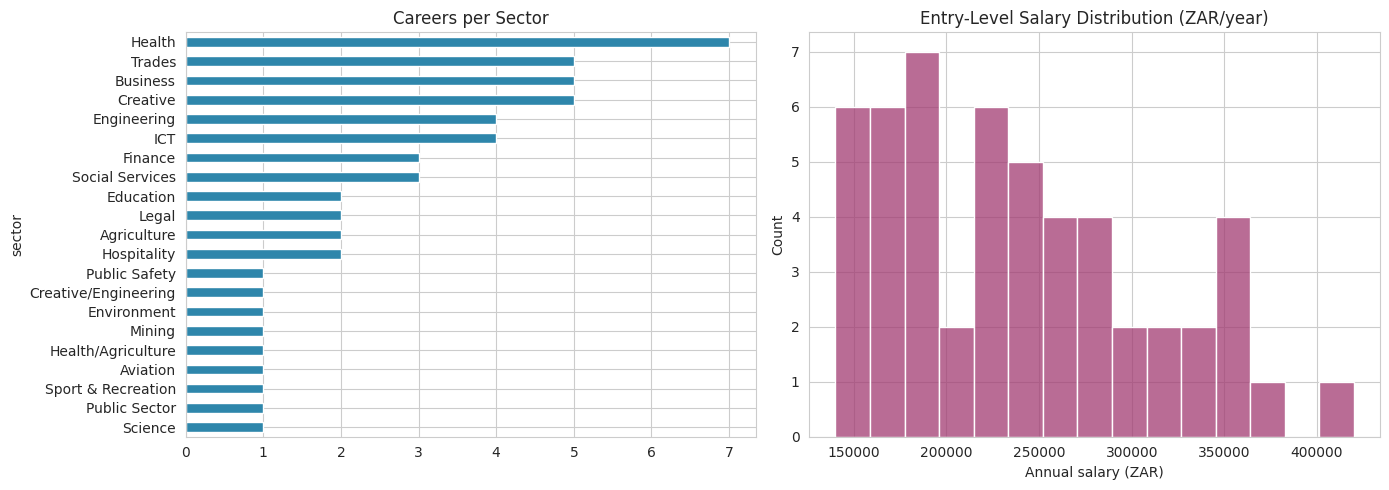

In [19]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

careers_df["sector"].value_counts().plot(kind="barh", ax=axes[0], color="#2E86AB")
axes[0].set_title("Careers per Sector")
axes[0].invert_yaxis()

sns.histplot(careers_df["salary_entry"].replace(0, np.nan).dropna(), bins=15, ax=axes[1], color="#A23B72")
axes[1].set_title("Entry-Level Salary Distribution (ZAR/year)")
axes[1].set_xlabel("Annual salary (ZAR)")

plt.tight_layout()
plt.show()



## 2. Questionnaire

A short, plain-language Likert-scale (1–5) quiz drives the whole system. It operationalises:
- **RIASEC interests** — 2 statements per dimension (12 items)
- **Big Five personality** — 2 statements per trait (10 items)
- **Academic marks** — per NSC subject
- **Practical constraints** — funding access and how long the student can study

This mirrors what a real web front-end would collect before calling the model.


In [20]:
"""
CareerCompass Questionnaire
============================
Short Likert-scale (1-5) quiz that operationalises the RIASEC interest
model and the Big Five personality traits, plus academic marks and
practical constraints. This is the layer a real web front-end would
collect from the user before calling the recommender.
"""

RIASEC_ITEMS = {
    "R": ["I enjoy fixing or building things with my hands.",
          "I'd rather work outdoors or with tools/machines than sit at a desk all day."],
    "I": ["I like figuring out how things work or solving puzzles.",
          "I enjoy science experiments or researching a topic deeply."],
    "A": ["I enjoy drawing, music, writing or other creative expression.",
          "I like coming up with original ideas rather than following a fixed method."],
    "S": ["I enjoy helping, teaching or caring for other people.",
          "I'd rather work in a team helping others than work alone."],
    "E": ["I enjoy leading a group or convincing people of an idea.",
          "I like taking initiative and starting new projects or ventures."],
    "C": ["I enjoy organising information, schedules or records.",
          "I prefer clear rules and structured tasks over ambiguity."],
}

BIG5_ITEMS = {
    "openness": ["I enjoy learning about new and unusual topics.",
                 "I like trying new approaches rather than sticking to routine."],
    "conscientiousness": ["I plan ahead and follow through on tasks.",
                           "I pay close attention to detail and accuracy."],
    "extraversion": ["I feel energised being around other people.",
                      "I speak up easily in group settings."],
    "agreeableness": ["I try to keep peace and support others' needs.",
                       "I find it easy to trust and cooperate with people."],
    "neuroticism": ["I get stressed easily under pressure.",
                     "My mood changes quickly when things go wrong."],
}

CONSTRAINT_QUESTIONS = {
    "budget_level": {
        "question": "What is your realistic funding access for further study?",
        "options": {1: "Very limited — need free/low-cost routes (TVET, learnerships, bursaries only)",
                    2: "Moderate — NSFAS/loan or part-funded is workable",
                    3: "Good — can access full university fees via bursary, loan or family support"}
    },
    "duration_pref": {
        "question": "How long are you willing/able to study before earning an income?",
        "options": {1: "Short — up to 2 years", 2: "Medium — 3 to 4 years", 3: "Long — 5+ years"}
    },
}


def likert_to_score(value):
    """Map a 1-5 Likert response to a 0-1 scale."""
    return (float(value) - 1) / 4.0


def score_riasec(answers):
    """answers: dict item_text -> 1-5 rating. Returns dict R..C -> 0-1."""
    scores = {}
    for dim, items in RIASEC_ITEMS.items():
        vals = [likert_to_score(answers[i]) for i in items if i in answers]
        scores[dim] = sum(vals) / len(vals) if vals else 0.5
    return scores


def score_big5(answers):
    scores = {}
    for trait, items in BIG5_ITEMS.items():
        vals = [likert_to_score(answers[i]) for i in items if i in answers]
        scores[trait] = sum(vals) / len(vals) if vals else 0.5
    return scores


def all_riasec_questions():
    return [q for items in RIASEC_ITEMS.values() for q in items]


def all_big5_questions():
    return [q for items in BIG5_ITEMS.values() for q in items]


In [21]:

print("RIASEC questions:")
for dim, items in RIASEC_ITEMS.items():
    for q in items:
        print(f"  [{dim}] {q}")

print("\nBig Five questions:")
for trait, items in BIG5_ITEMS.items():
    for q in items:
        print(f"  [{trait}] {q}")


RIASEC questions:
  [R] I enjoy fixing or building things with my hands.
  [R] I'd rather work outdoors or with tools/machines than sit at a desk all day.
  [I] I like figuring out how things work or solving puzzles.
  [I] I enjoy science experiments or researching a topic deeply.
  [A] I enjoy drawing, music, writing or other creative expression.
  [A] I like coming up with original ideas rather than following a fixed method.
  [S] I enjoy helping, teaching or caring for other people.
  [S] I'd rather work in a team helping others than work alone.
  [E] I enjoy leading a group or convincing people of an idea.
  [E] I like taking initiative and starting new projects or ventures.
  [C] I enjoy organising information, schedules or records.
  [C] I prefer clear rules and structured tasks over ambiguity.

Big Five questions:
  [openness] I enjoy learning about new and unusual topics.
  [openness] I like trying new approaches rather than sticking to routine.
  [conscientiousness] I plan ahe


## 3. Synthetic Training Data

Real individually-labelled "which career did this exact student end up thriving in" data isn't
publicly available for South Africa. We bootstrap a realistic training set by sampling synthetic
student profiles **around each career's ideal profile** (70% of samples, with Gaussian noise on
interests/personality/marks) plus a smaller share of fully random ("undecided") students labelled
by the content-based scorer. This is a standard weak-supervision / distillation approach: it lets
a downstream ML classifier learn *generalisable* patterns (e.g. "high Investigative interest +
strong Maths/Science marks → Health/Engineering sectors") rather than memorising the raw rules.


In [22]:
"""
CareerCompass Recommender Engine
=================================
Hybrid architecture:
  1. CONTENT-BASED layer: cosine similarity between a student's RIASEC
     interest vector / personality vector and each career's ideal profile,
     plus a rule-based academic-subject match and a practical-constraints
     filter (budget, study duration).
  2. ML layer: a RandomForestClassifier trained on simulated student
     profiles (labelled by the content-based scorer acting as a weak
     supervisor, a common "distillation" pattern used when real labelled
     outcome data isn't available) predicts a probability distribution
     over career SECTORS. Sector probabilities are then used to re-rank
     and boost the content-based career scores, and the model's
     feature_importances_ give a global interpretability view.
  3. EXPLANATION layer: turns the numeric match into a plain-English
     reason string per recommendation.

This keeps the system interpretable (every recommendation can be traced
back to specific RIASEC dimensions, subjects and personality traits)
while still being "ML-powered" via the supervised sector classifier.
"""

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, top_k_accuracy_score
from sklearn.metrics.pairwise import cosine_similarity


RNG = np.random.default_rng(42)


# ----------------------------------------------------------------------
# 1. SYNTHETIC STUDENT PROFILE GENERATION (for training the ML layer)
# ----------------------------------------------------------------------
def _sample_student(career_bias=None):
    """
    Sample one synthetic student. If career_bias is given (a career dict),
    the profile is generated *around* that career's ideal profile with
    noise, so the dataset contains a realistic mixture of "good fits" for
    every career alongside pure-random students. This avoids a purely
    self-referential labelling loop and gives the classifier real signal
    to learn from.
    """
    if career_bias is not None and RNG.random() < 0.7:
        riasec = {k: float(np.clip(career_bias["riasec"][k] + RNG.normal(0, 0.18), 0, 1))
                  for k in RIASEC_KEYS}
        personality = {k: float(np.clip(career_bias["personality"][k] + RNG.normal(0, 0.15), 0, 1))
                       for k in BIG5_KEYS}
        subjects = {}
        for s in ALL_SUBJECTS:
            base = career_bias["subjects"].get(s, 45)
            subjects[s] = float(np.clip(RNG.normal(base + 5, 15), 20, 100))
        budget_level = int(np.clip(career_bias["budget_level"] + RNG.integers(-1, 2), 1, 3))
    else:
        riasec = {k: float(RNG.uniform(0.1, 0.95)) for k in RIASEC_KEYS}
        personality = {k: float(RNG.uniform(0.15, 0.9)) for k in BIG5_KEYS}
        subjects = {s: float(np.clip(RNG.normal(55, 18), 20, 100)) for s in ALL_SUBJECTS}
        budget_level = int(RNG.integers(1, 4))

    duration_pref = int(RNG.integers(1, 4))  # 1=short(<=2y) 2=medium(3-4y) 3=long(5y+)
    location = RNG.choice(["urban", "peri-urban", "rural"])

    return dict(riasec=riasec, personality=personality, subjects=subjects,
                budget_level=budget_level, duration_pref=duration_pref, location=location)


def generate_training_data(n_per_career=40):
    rows = []
    for career in CAREERS:
        for _ in range(n_per_career):
            s = _sample_student(career_bias=career)
            rows.append({**_flatten_student(s), "career": career["name"], "sector": career["sector"]})
    # add pure-random ("undecided") students, labelled by best content-based match
    for _ in range(int(n_per_career * len(CAREERS) * 0.15)):
        s = _sample_student(career_bias=None)
        best = max(CAREERS, key=lambda c: _content_score(s, c)["total"])
        rows.append({**_flatten_student(s), "career": best["name"], "sector": best["sector"]})
    df = pd.DataFrame(rows)
    return df.sample(frac=1, random_state=42).reset_index(drop=True)


def _flatten_student(s):
    flat = {}
    for k in RIASEC_KEYS:
        flat[f"riasec_{k}"] = s["riasec"][k]
    for k in BIG5_KEYS:
        flat[f"big5_{k}"] = s["personality"][k]
    for subj in ALL_SUBJECTS:
        flat[f"subj_{subj}"] = s["subjects"][subj]
    flat["budget_level"] = s["budget_level"]
    flat["duration_pref"] = s["duration_pref"]
    flat["location"] = s["location"]
    return flat


FEATURE_COLS = (
    [f"riasec_{k}" for k in RIASEC_KEYS] +
    [f"big5_{k}" for k in BIG5_KEYS] +
    [f"subj_{s}" for s in ALL_SUBJECTS] +
    ["budget_level", "duration_pref"]
)


# ----------------------------------------------------------------------
# 2. CONTENT-BASED SCORING (interpretable layer, also used to label data)
# ----------------------------------------------------------------------
def _content_score(student, career):
    riasec_vec = np.array([student["riasec"][k] for k in RIASEC_KEYS]).reshape(1, -1)
    career_riasec_vec = np.array([career["riasec"][k] for k in RIASEC_KEYS]).reshape(1, -1)
    riasec_sim = float(cosine_similarity(riasec_vec, career_riasec_vec)[0, 0])

    pers_vec = np.array([student["personality"][k] for k in BIG5_KEYS]).reshape(1, -1)
    career_pers_vec = np.array([career["personality"][k] for k in BIG5_KEYS]).reshape(1, -1)
    pers_sim = float(cosine_similarity(pers_vec, career_pers_vec)[0, 0])

    # subject match: fraction of required subjects met at/above the minimum
    req = career["subjects"]
    if req:
        met = [1.0 if student["subjects"].get(subj, 0) >= min_mark else
               max(0.0, student["subjects"].get(subj, 0) / min_mark)
               for subj, min_mark in req.items()]
        subject_score = float(np.mean(met))
    else:
        subject_score = 0.8  # no hard subject requirement

    # constraint match: budget affordability + duration alignment
    budget_ok = 1.0 if student["budget_level"] >= career["budget_level"] else 0.4
    dur_bucket = 1 if career["duration_years"] <= 2 else (2 if career["duration_years"] <= 4 else 3)
    duration_ok = 1.0 if student["duration_pref"] == dur_bucket else (0.6 if abs(student["duration_pref"] - dur_bucket) == 1 else 0.3)
    constraint_score = 0.5 * budget_ok + 0.5 * duration_ok

    total = 0.40 * riasec_sim + 0.20 * pers_sim + 0.30 * subject_score + 0.10 * constraint_score
    return dict(total=total, riasec_sim=riasec_sim, pers_sim=pers_sim,
                subject_score=subject_score, constraint_score=constraint_score)


# ----------------------------------------------------------------------
# 3. ML MODEL (sector classifier)
# ----------------------------------------------------------------------
class CareerRecommender:
    def __init__(self):
        self.model = RandomForestClassifier(
            n_estimators=300, max_depth=14, min_samples_leaf=2,
            random_state=42, n_jobs=-1, class_weight="balanced"
        )
        self.le_sector = LabelEncoder()
        self.train_report = {}

    def fit(self, df):
        X = df[FEATURE_COLS].copy()
        y_sector = self.le_sector.fit_transform(df["sector"])
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_sector, test_size=0.2, random_state=42, stratify=y_sector
        )
        self.model.fit(X_train, y_train)
        y_pred = self.model.predict(X_test)
        proba = self.model.predict_proba(X_test)
        acc = accuracy_score(y_test, y_pred)
        present_labels = np.unique(y_train)
        top3 = top_k_accuracy_score(y_test, proba, k=3, labels=present_labels)
        self.train_report = dict(
            n_train=len(X_train), n_test=len(X_test),
            n_classes=len(self.le_sector.classes_),
            accuracy=acc, top3_accuracy=top3
        )
        return self.train_report

    def feature_importances(self, top_n=15):
        importances = pd.Series(self.model.feature_importances_, index=FEATURE_COLS)
        return importances.sort_values(ascending=False).head(top_n)

    def _sector_probabilities(self, student):
        x = pd.DataFrame([_flatten_student(student)])[FEATURE_COLS]
        proba = self.model.predict_proba(x)[0]
        return dict(zip(self.le_sector.classes_, proba))

    def recommend(self, student, top_n=5, apply_constraints=True):
        sector_proba = self._sector_probabilities(student)
        results = []
        for career in CAREERS:
            content = _content_score(student, career)
            ml_boost = sector_proba.get(career["sector"], 0.0)
            # blend: content-based score is primary (interpretable, precise to the
            # individual career) with the ML sector-probability as a re-ranking boost
            final_score = 0.75 * content["total"] + 0.25 * ml_boost
            results.append({
                "career": career["name"], "sector": career["sector"], "career_obj": career,
                "final_score": final_score, "ml_sector_confidence": ml_boost, **content
            })
        results.sort(key=lambda r: r["final_score"], reverse=True)

        if apply_constraints:
            affordable = [r for r in results if student["budget_level"] >= r["career_obj"]["budget_level"] - 1]
            ranked = affordable if len(affordable) >= top_n else results
        else:
            ranked = results

        top = ranked[:top_n]
        for r in top:
            r["explanation"] = _explain(student, r)
        return top


# ----------------------------------------------------------------------
# 4. EXPLANATION GENERATOR
# ----------------------------------------------------------------------
def _explain(student, result):
    career = result["career_obj"]
    reasons = []

    # top matching RIASEC dimension(s)
    diffs = {k: student["riasec"][k] * career["riasec"][k] for k in RIASEC_KEYS}
    top_dim = max(diffs, key=diffs.get)
    dim_names = dict(R="hands-on/practical work", I="investigating and analytical problem-solving",
                      A="creative and artistic expression", S="helping and working with people",
                      E="leading, persuading and enterprising activity", C="organised, detail-oriented work")
    if diffs[top_dim] > 0.3:
        reasons.append(f"Your interest profile strongly matches {dim_names[top_dim]}, "
                        f"which is central to this career (interest fit: {result['riasec_sim']*100:.0f}%).")

    # subjects
    req = career["subjects"]
    if req:
        met = [s for s, m in req.items() if student["subjects"].get(s, 0) >= m]
        short = [s for s, m in req.items() if student["subjects"].get(s, 0) < m]
        if met:
            reasons.append(f"You meet the marks needed in {', '.join(met)}.")
        if short:
            gap = ", ".join(f"{s} (need {m}%, currently {student['subjects'].get(s,0):.0f}%)"
                             for s, m in req.items() if s in short)
            reasons.append(f"You'll need to raise: {gap}.")
    else:
        reasons.append("This career has no strict subject cut-offs, widening access.")

    # personality
    if result["pers_sim"] > 0.85:
        reasons.append("Your personality traits closely align with people who thrive in this role.")

    # constraints
    if student["budget_level"] < career["budget_level"]:
        reasons.append("Note: this path is typically costlier — look into NSFAS, SETA or sector bursaries below.")
    else:
        reasons.append("This path fits within your indicated budget/funding access.")

    return " ".join(reasons)


def student_from_answers(academic_marks, riasec_scores, personality_scores, budget_level, duration_pref, location="urban"):
    """Convenience constructor turning raw questionnaire answers into the
    student-profile dict the recommender expects."""
    subjects = {s: float(academic_marks.get(s, 45)) for s in ALL_SUBJECTS}
    riasec = {k: float(riasec_scores.get(k, 0.5)) for k in RIASEC_KEYS}
    personality = {k: float(personality_scores.get(k, 0.5)) for k in BIG5_KEYS}
    return dict(riasec=riasec, personality=personality, subjects=subjects,
                budget_level=int(budget_level), duration_pref=int(duration_pref), location=location)




In [23]:

df = generate_training_data(n_per_career=45)
print(df.shape)
df.head()


(2742, 25)


,riasec_R,riasec_I,riasec_A,riasec_S,riasec_E,riasec_C,big5_openness,big5_conscientiousness,big5_extraversion,big5_agreeableness,big5_neuroticism,subj_Accounting,subj_Business Studies,subj_Economics,subj_English,subj_Geography,subj_History,subj_Life Sciences,subj_Mathematics,subj_Physical Sciences,budget_level,duration_pref,location,career,sector
0,0.584027,0.280237,0.451330,0.157028,0.504070,0.460307,0.249545,0.483279,0.629649,0.846368,0.677389,54.659682,58.890822,59.036648,36.500137,56.953967,74.121703,81.508438,34.339331,27.665178,1,2,peri-urban,Human Resources Manager,Business
1,0.846828,0.441807,0.706519,0.642665,0.559795,0.228877,0.581582,0.373943,0.677692,0.858639,0.695743,52.693282,37.400649,27.966991,69.256555,63.519813,59.742269,35.461055,58.788357,31.411663,3,1,rural,Journalist / Media Writer,Creative
2,0.092156,0.794506,0.299479,0.337486,0.583420,0.678881,0.411976,0.769124,0.341281,0.067583,0.193888,51.909287,33.568787,70.668082,54.299497,63.687958,56.280051,82.645031,58.097590,28.305859,1,3,rural,Attorney / Lawyer,Legal
3,0.416115,0.464994,0.654478,0.643648,0.925508,0.578424,0.390739,0.365579,0.550514,0.239669,0.591074,49.980952,78.454210,42.364710,84.025381,44.688279,35.771911,59.565467,67.223296,58.385582,3,3,urban,Police Officer,Public Safety
4,0.888039,0.462756,0.456042,0.802539,0.525759,0.080362,0.412267,0.610636,0.867165,0.562624,0.359519,50.385969,46.172116,29.444131,27.888153,46.443646,47.317115,48.343286,53.701260,80.979702,2,3,rural,Sports Coach / Biokineticist,Sport & Recreation


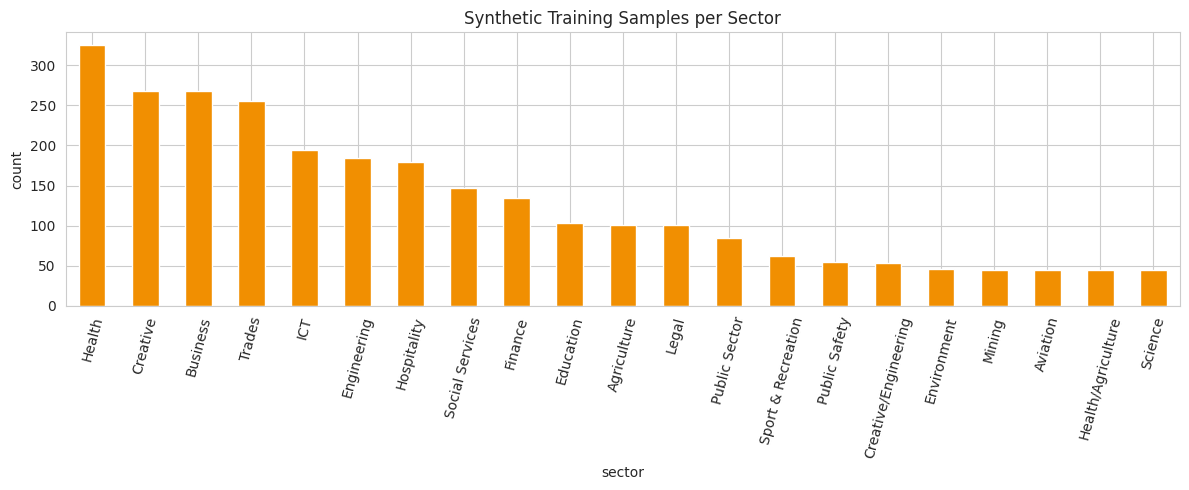

In [24]:

fig, ax = plt.subplots(figsize=(12, 5))
df["sector"].value_counts().plot(kind="bar", ax=ax, color="#F18F01")
ax.set_title("Synthetic Training Samples per Sector")
ax.set_ylabel("count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()



## 4. Model Training

`RandomForestClassifier` predicts the most suitable **career sector** from the student's full
feature vector (RIASEC + Big Five + subject marks + constraints). Random Forests were chosen
because they:
- Handle mixed numeric feature scales well without heavy preprocessing,
- Are naturally multi-class,
- Provide **feature_importances_** for interpretability — important since this is a guidance
  tool that must be able to explain *why* it recommends something, not just output a black-box score.

The sector prediction is then blended with the content-based per-career score (see Section 5) to
produce the final, individually explainable ranking.


In [25]:

recommender = CareerRecommender()
report = recommender.fit(df)
print("Training report:")
for k, v in report.items():
    print(f"  {k}: {v}")


Training report:
  n_train: 2193
  n_test: 549
  n_classes: 21
  accuracy: 0.41712204007285975
  top3_accuracy: 0.6593806921675774


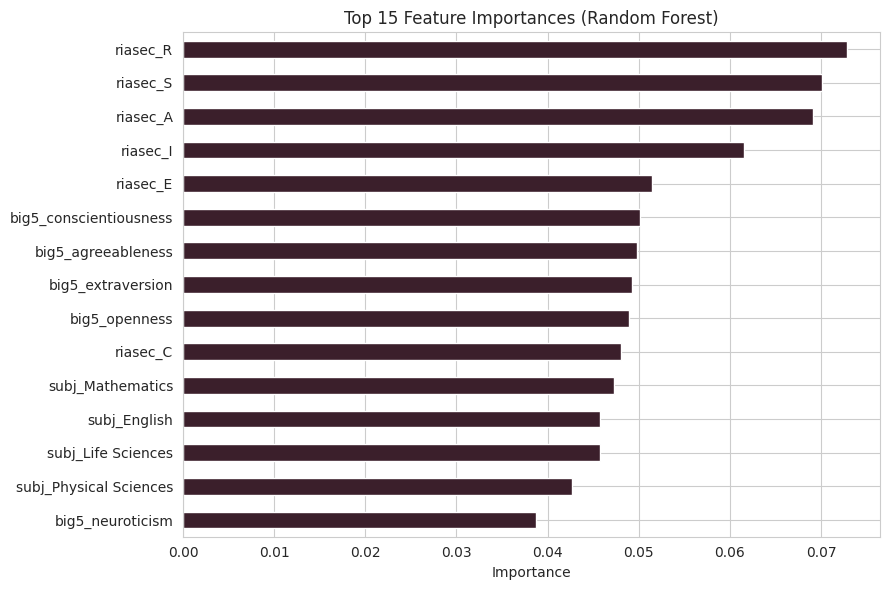

In [26]:

# Feature importance chart
importances = recommender.feature_importances(top_n=15)
fig, ax = plt.subplots(figsize=(9, 6))
importances.sort_values().plot(kind="barh", ax=ax, color="#3B1F2B")
ax.set_title("Top 15 Feature Importances (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()



**Reading the chart:** RIASEC dimensions (especially Social, Realistic, Artistic, Investigative)
and personality traits like Agreeableness/Openness dominate — consistent with career-guidance
theory, where *interest fit* is the strongest predictor of career satisfaction, with academic
marks acting as a hard gate rather than a ranking signal (handled separately in the content-based
layer below).



## 5. Hybrid Recommendation & Explanation Engine

For an individual student, each of the 53 careers is scored using:

$$\text{final\_score} = 0.75 \times \underbrace{(0.40\,\text{RIASEC sim} + 0.20\,\text{personality sim} + 0.30\,\text{subject match} + 0.10\,\text{constraint match})}_{\text{content-based score}} \;+\; 0.25 \times \underbrace{P(\text{sector} \mid \text{student})}_{\text{ML re-ranking boost}}$$

Careers are then filtered by budget feasibility (with a soft one-tier tolerance) and the top-N
are returned, each with a natural-language explanation.


In [27]:

demo_student = student_from_answers(
    academic_marks={"Mathematics": 78, "Physical Sciences": 74, "Life Sciences": 70, "English": 65,
                     "Accounting": 55, "Business Studies": 50},
    riasec_scores={"R": 0.3, "I": 0.9, "A": 0.2, "S": 0.6, "E": 0.3, "C": 0.5},
    personality_scores={"openness": 0.6, "conscientiousness": 0.85, "extraversion": 0.4,
                         "agreeableness": 0.6, "neuroticism": 0.2},
    budget_level=2, duration_pref=2, location="urban"
)

recs = recommender.recommend(demo_student, top_n=5)

for i, r in enumerate(recs, 1):
    c = r["career_obj"]
    print(f"{i}. {r['career']}  (match score: {r['final_score']*100:.0f}%, sector: {r['sector']})")
    print(f"   {r['explanation']}")
    print(f"   Pathway: {c['description']}")
    print(f"   Next steps: {'; '.join(c['next_steps'])}")
    print()


1. Radiographer  (match score: 82%, sector: Health)
   Your interest profile strongly matches investigating and analytical problem-solving, which is central to this career (interest fit: 97%). You meet the marks needed in Mathematics, Physical Sciences, Life Sciences. Your personality traits closely align with people who thrive in this role. This path fits within your indicated budget/funding access.
   Pathway: Operate imaging equipment (X-ray, CT, MRI) to diagnose conditions.
   Next steps: Keep Physical Sciences above 55%; Apply to Diagnostic Radiography programmes

2. Pharmacist  (match score: 80%, sector: Health)
   Your interest profile strongly matches investigating and analytical problem-solving, which is central to this career (interest fit: 99%). You meet the marks needed in Mathematics, Physical Sciences, Life Sciences. Your personality traits closely align with people who thrive in this role. Note: this path is typically costlier — look into NSFAS, SETA or sector bursaries 

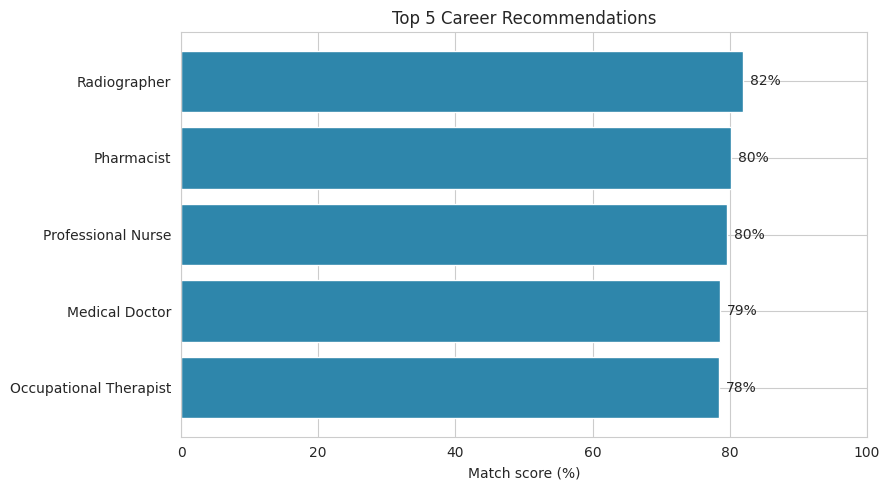

In [28]:

fig, ax = plt.subplots(figsize=(9, 5))
names = [r["career"] for r in recs][::-1]
scores = [r["final_score"] * 100 for r in recs][::-1]
bars = ax.barh(names, scores, color="#2E86AB")
ax.set_xlabel("Match score (%)")
ax.set_title(f"Top {len(recs)} Career Recommendations")
ax.set_xlim(0, 100)
for bar, score in zip(bars, scores):
    ax.text(score + 1, bar.get_y() + bar.get_height()/2, f"{score:.0f}%", va="center")
plt.tight_layout()
plt.show()



## 6. Interactive Demo (Questionnaire → Recommendations)

Run the cell below in Kaggle (or any Jupyter environment with `ipywidgets`) to answer the
questionnaire interactively and get live recommendations. If widgets aren't rendering
(e.g. in a plain script export), use the **manual profile builder** in the cell after it instead.


In [29]:

import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

riasec_qs = all_riasec_questions()
big5_qs = all_big5_questions()
subject_list = ["Mathematics", "Physical Sciences", "Life Sciences", "Accounting",
                 "Business Studies", "Economics", "English", "Geography", "History"]

riasec_sliders = {q: widgets.IntSlider(value=3, min=1, max=5, description=f"Q{i+1}", style={'description_width':'40px'}, layout=widgets.Layout(width='500px')) for i, q in enumerate(riasec_qs)}
big5_sliders = {q: widgets.IntSlider(value=3, min=1, max=5, description=f"Q{i+1}", style={'description_width':'40px'}, layout=widgets.Layout(width='500px')) for i, q in enumerate(big5_qs)}
subject_inputs = {s: widgets.BoundedIntText(value=55, min=0, max=100, description=s, style={'description_width':'150px'}) for s in subject_list}

budget_dd = widgets.Dropdown(options=[(v["options"][k], k) for k in v["options"]] if (v:=CONSTRAINT_QUESTIONS["budget_level"]) else [], description="Budget:")
duration_dd = widgets.Dropdown(options=[(v["options"][k], k) for k in v["options"]] if (v:=CONSTRAINT_QUESTIONS["duration_pref"]) else [], description="Duration:")

run_btn = widgets.Button(description="Get My Recommendations", button_style="success", icon="compass")
output = widgets.Output()

def on_click(b):
    with output:
        clear_output()
        riasec_answers = {q: s.value for q, s in riasec_sliders.items()}
        big5_answers = {q: s.value for q, s in big5_sliders.items()}
        marks = {s: w.value for s, w in subject_inputs.items()}
        riasec_scores = score_riasec(riasec_answers)
        big5_scores = score_big5(big5_answers)
        student = student_from_answers(marks, riasec_scores, big5_scores,
                                        budget_level=budget_dd.value, duration_pref=duration_dd.value)
        results = recommender.recommend(student, top_n=5)
        display(Markdown("### 🎯 Your Top Career Matches"))
        for i, r in enumerate(results, 1):
            c = r["career_obj"]
            display(Markdown(
                f"**{i}. {r['career']}** — {r['final_score']*100:.0f}% match  \n"
                f"*{r['explanation']}*  \n"
                f"**Pathway:** {c['description']}  \n"
                f"**Next steps:** {'; '.join(c['next_steps'])}\n\n---"
            ))

run_btn.on_click(on_click)

display(Markdown("#### Interest Questions (1 = strongly disagree, 5 = strongly agree)"))
display(widgets.VBox(list(riasec_sliders.values())))
display(Markdown("#### Personality Questions (1 = strongly disagree, 5 = strongly agree)"))
display(widgets.VBox(list(big5_sliders.values())))
display(Markdown("#### Your Academic Marks (%)"))
display(widgets.VBox(list(subject_inputs.values())))
display(Markdown("#### Practical Constraints"))
display(widgets.HBox([budget_dd, duration_dd]))
display(run_btn, output)


#### Interest Questions (1 = strongly disagree, 5 = strongly agree)

#### Personality Questions (1 = strongly disagree, 5 = strongly agree)

#### Your Academic Marks (%)

#### Practical Constraints

Button(button_style='success', description='Get My Recommendations', icon='compass', style=ButtonStyle())

Output()


### Manual profile builder (fallback, no widgets required)
Edit the dictionaries below directly and re-run to test any student scenario headlessly —
useful for automated testing or if interactive widgets are disabled in your environment.


In [30]:

manual_student = student_from_answers(
    academic_marks={"Mathematics": 55, "English": 60, "Life Sciences": 65, "History": 70},
    riasec_scores={"R": 0.2, "I": 0.3, "A": 0.4, "S": 0.9, "E": 0.5, "C": 0.4},
    personality_scores={"openness": 0.6, "conscientiousness": 0.7, "extraversion": 0.6,
                         "agreeableness": 0.85, "neuroticism": 0.3},
    budget_level=1,     # 1 = very limited funding
    duration_pref=1,    # 1 = short study path preferred
)

for i, r in enumerate(recommender.recommend(manual_student, top_n=5), 1):
    print(f"{i}. {r['career']} — {r['final_score']*100:.0f}% match")
    print(f"   {r['explanation']}\n")


1. Foundation Phase Teacher — 81% match
   Your interest profile strongly matches helping and working with people, which is central to this career (interest fit: 99%). You meet the marks needed in Mathematics, English. Your personality traits closely align with people who thrive in this role. This path fits within your indicated budget/funding access.

2. Community Development Worker — 81% match
   Your interest profile strongly matches helping and working with people, which is central to this career (interest fit: 98%). You meet the marks needed in English. Your personality traits closely align with people who thrive in this role. This path fits within your indicated budget/funding access.

3. High School Subject Teacher — 81% match
   Your interest profile strongly matches helping and working with people, which is central to this career (interest fit: 97%). You meet the marks needed in Mathematics, English. Your personality traits closely align with people who thrive in this role. Th


## 7. Model Evaluation Summary

Because career fit is inherently a "several good options" problem (not a single right answer),
**top-3 accuracy at the sector level** is the more meaningful metric than raw top-1 accuracy —
it reflects whether the model surfaces *a* correct sector among its short-list, which is exactly
how the hybrid layer uses it (as a re-ranking signal across 53 individual careers, not as the
sole decision).


In [31]:

summary = pd.DataFrame([{
    "Metric": "Sector classes", "Value": report["n_classes"]
}, {
    "Metric": "Training samples", "Value": report["n_train"]
}, {
    "Metric": "Test samples", "Value": report["n_test"]
}, {
    "Metric": "Top-1 Accuracy", "Value": f"{report['accuracy']*100:.1f}%"
}, {
    "Metric": "Top-3 Accuracy", "Value": f"{report['top3_accuracy']*100:.1f}%"
}])
summary


,Metric,Value
0,Sector classes,21
1,Training samples,2193
2,Test samples,549
3,Top-1 Accuracy,41.7%
4,Top-3 Accuracy,65.9%


In [32]:
# Save the trained model + label encoder + career DB for deployment
joblib.dump(recommender.model, "careercompass_rf_model.joblib")
joblib.dump(recommender.le_sector, "careercompass_label_encoder.joblib")
careers_df.to_json("careercompass_careers.json", orient="records")
print("Artifacts saved: careercompass_rf_model.joblib, careercompass_label_encoder.joblib, careercompass_careers.json")


Artifacts saved: careercompass_rf_model.joblib, careercompass_label_encoder.joblib, careercompass_careers.json



## 8. From Notebook to Web App — Deployment Notes

This notebook is the ML core. To ship the "personalised career advisory web app" from the brief:

1. **Package the model** — the saved `.joblib` files + `careers_data.py` + `recommender.py`
   + `questionnaire.py` are all you need to serve predictions; no retraining required at request time.
2. **Backend API** — wrap `CareerRecommender.recommend()` in a lightweight FastAPI/Flask service
   exposing a `POST /recommend` endpoint that accepts the questionnaire answers as JSON.
3. **Frontend** — a simple mobile-first React/Streamlit form (works on low-end phones/low
   bandwidth, important for reaching youth without reliable connectivity) posts to that endpoint
   and renders the ranked careers, explanations and next steps.
4. **Streamlit quick-deploy option** — for the fastest path to a public link, wrap the same
   recommender in a `streamlit_app.py` (a few dozen lines reusing the functions above) and deploy
   to Streamlit Community Cloud or Hugging Face Spaces for free.
5. **Data flywheel** — once real users start choosing/rating recommendations, log
   (profile → chosen career → later self-reported satisfaction) pairs and periodically retrain
   `CareerRecommender` on real outcomes instead of the synthetic bootstrap set, closing the loop
   from "content-based + weak supervision" to a fully data-driven model.
6. **Expand the career base** — integrate live O\*NET Interest Profiler data (translated/adapted)
   and SETA/DHET labour-market datasets (scarce-skills lists, bursary databases) as they update,
   rather than the static curated list used here.

This design keeps the *guidance logic* transparent and auditable (a hard requirement for a tool
advising minors on life-shaping decisions), while still using a trained ML model where it adds
real value — spotting cross-cutting patterns across interests, personality and marks that a
pure rules engine would miss.
